# End-to-End Sales Analytics Project

## Business Objective

This project simulates a real-world business analytics workflow, transforming raw transactional sales data into structured insights using SQL, PostgreSQL, and Python.

This analysis aims to:
- Identify top-performing regions and product categories
- Measure profitability and profit margins
- Detect seasonality and sales trends over time
- Provide actionable insights to improve business performance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
# Check missing values
df.isnull().sum()

# Drop only important missing values
df = df.dropna(subset=['Order Date', 'Ship Date', 'Sales'])

# Remove duplicates
df = df.drop_duplicates()

# Convert date columns (day first format)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

# Convert sales to numeric
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Drop rows where conversion failed
df = df.dropna(subset=['Order Date', 'Ship Date', 'Sales'])

# Feature engineering
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Order Quarter'] = df['Order Date'].dt.quarter





In [5]:
quarterly_sales = df.groupby(['Order Year', 'Order Quarter'])['Sales'].sum().reset_index()
quarterly_sales['Year-Quarter'] = (
    quarterly_sales['Order Year'].astype(str) + 
    ' Q' + 
    quarterly_sales['Order Quarter'].astype(str)
)

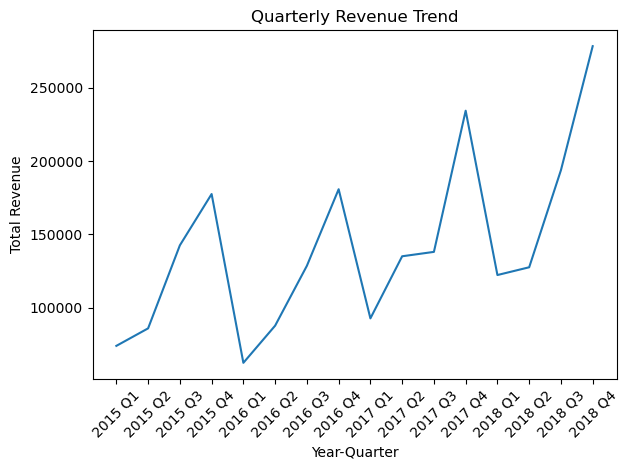

In [6]:
plt.figure()
plt.plot(quarterly_sales['Year-Quarter'], quarterly_sales['Sales'])
plt.xticks(rotation=45)
plt.title("Quarterly Revenue Trend")
plt.xlabel("Year-Quarter")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

In [12]:
# Shipping performance
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

# Quarter
df['Order Quarter'] = df['Order Date'].dt.quarter

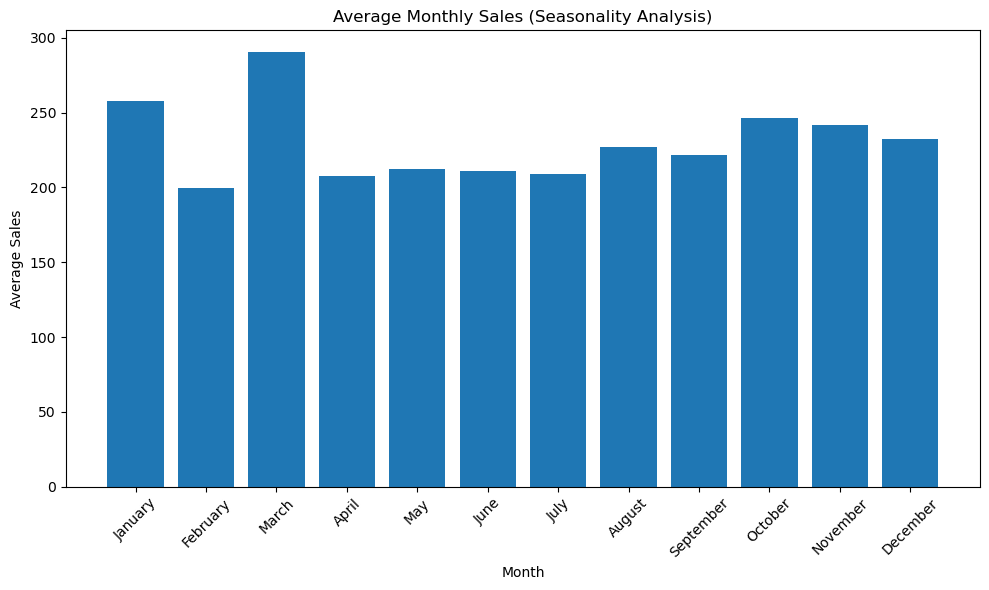

In [16]:
#### Monthly average sales


# Ensure month name exists
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Order Month'] = df['Order Date'].dt.month

# Sort months correctly (Jan → Dec)
monthly_avg = (
    df.groupby(['Order Month','Order Month Name'])['Sales']
      .mean()
      .reset_index()
      .sort_values('Order Month')
)
monthly_avg

plt.figure(figsize=(10,6))
plt.bar(monthly_avg['Order Month Name'], monthly_avg['Sales'])
plt.xticks(rotation=45)
plt.title("Average Monthly Sales (Seasonality Analysis)")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

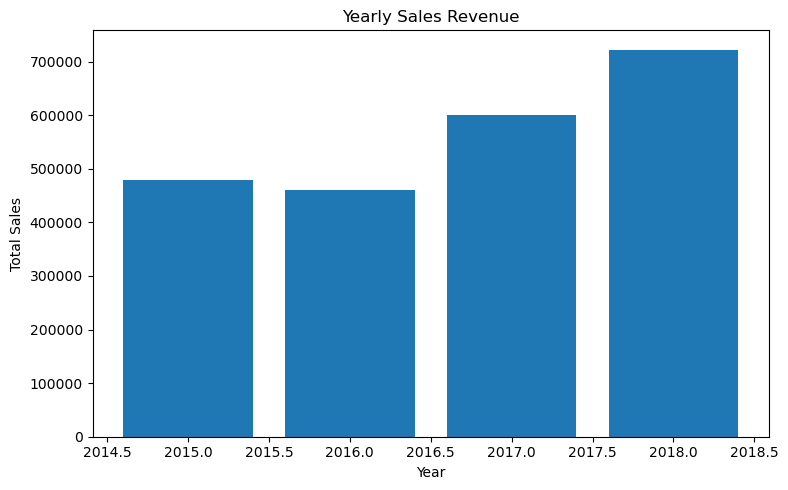

In [18]:
# Year over year growth

yearly_sales = (
    df.groupby('Order Year')['Sales']
      .sum()
      .reset_index()
      .sort_values('Order Year')
)

yearly_sales

# Visualize using bar chart

plt.figure(figsize=(8,5))
plt.bar(yearly_sales['Order Year'], yearly_sales['Sales'])
plt.title("Yearly Sales Revenue")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

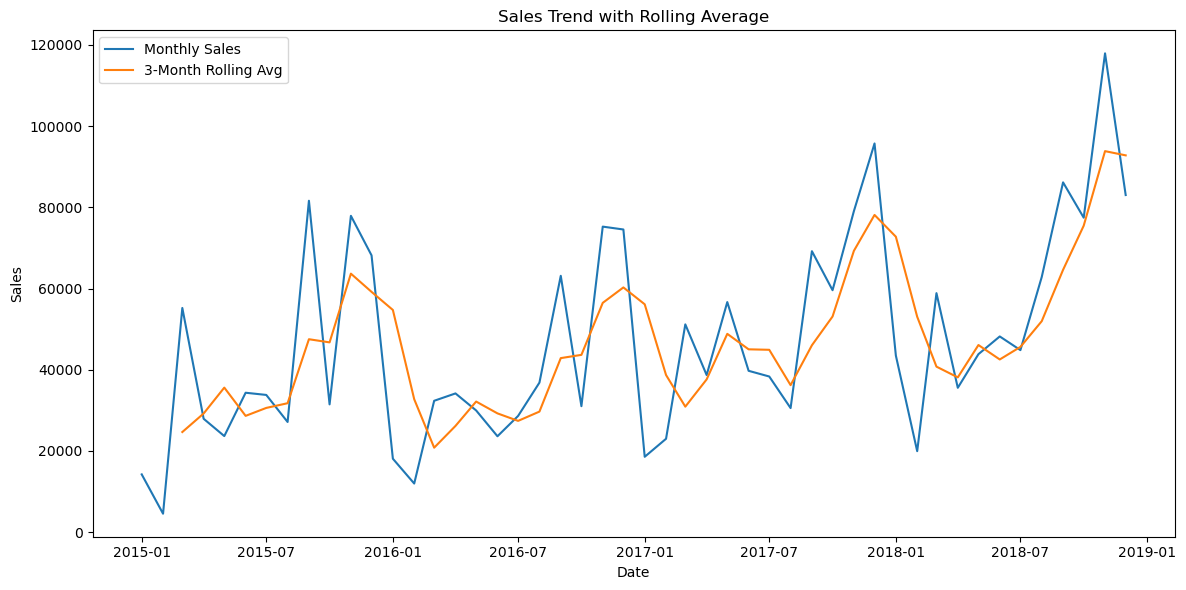

In [20]:
monthly_sales = (
    df.groupby(['Order Year','Order Month'])['Sales']
      .sum()
      .reset_index()
      .sort_values(['Order Year','Order Month'])
)

# Create proper date column
monthly_sales['Date'] = pd.to_datetime(
    monthly_sales['Order Year'].astype(str) + '-' +
    monthly_sales['Order Month'].astype(str) + '-01'
)

# Rolling average
monthly_sales['Rolling Avg (3M)'] = (
    monthly_sales['Sales'].rolling(window=3).mean()
)

plt.figure(figsize=(12,6))

plt.plot(monthly_sales['Date'], monthly_sales['Sales'], label='Monthly Sales')
plt.plot(monthly_sales['Date'], monthly_sales['Rolling Avg (3M)'], label='3-Month Rolling Avg')

plt.title("Sales Trend with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()